# Plot mean $R^2$

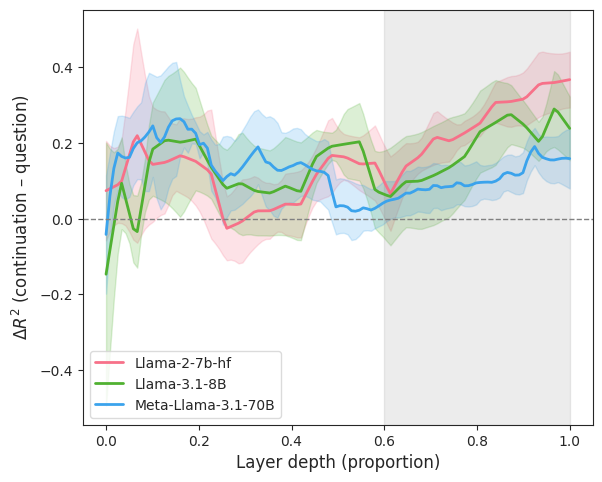

In [ ]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem
import seaborn as sns

# === 0. Set plotting style with light grid lines ===
sns.set_style('whitegrid', {
    'grid.color': 'lightgray',
    'grid.linestyle': '--',
    'axes.edgecolor': 'gray'
})

sns.set_style('ticks') 

# === 1. Configuration: path to JSON files ===
base_dir = 'Results/question_continuation'

# === 2. Find all JSON files ===
json_files = glob.glob(os.path.join(base_dir, '*.json'))
if not json_files:
    raise FileNotFoundError(f"No JSON files found in {base_dir}. Please check the path.")

# === 3. Load data ===
data = {}
for fp in json_files:
    attribute = os.path.splitext(os.path.basename(fp))[0].replace('r2_scores_', '')
    with open(fp, 'r') as f:
        obj = json.load(f)
    data[attribute] = {}
    for key, arr in obj.items():
        if 'continuation prompt' in key:
            model = key.replace(' (continuation prompt)', '')
            slot = 'nonmatching'
        elif 'question prompt' in key:
            model = key.replace(' (question prompt)', '')
            slot = 'matching'
        else:
            continue
        data[attribute].setdefault(model, {})[slot] = np.array(arr, dtype=float)

# === 4. Depth grid ===
depth_grid = np.linspace(0, 1, 120)

# === 5. Compute ΔR² curves ===
model_deltas = {}
for attribute, models in data.items():
    for model, tokens in models.items():
        if 'matching' in tokens and 'nonmatching' in tokens:
            match_arr = tokens['matching']
            nonmatch_arr = tokens['nonmatching']
            depths = np.linspace(0, 1, len(match_arr))
            m_interp = np.interp(depth_grid, depths, match_arr)
            nm_interp = np.interp(depth_grid, depths, nonmatch_arr)
            delta = nm_interp - m_interp
            model_deltas.setdefault(model, []).append(delta)

# === 6. Plot with improved aspect ratio and legend ===
fig, ax = plt.subplots(figsize=(6, 5))   # Taller figure

# Generate color palette
models = list(model_deltas.keys())
colors = sns.color_palette("husl", len(models))

for i, (model, deltas) in enumerate(model_deltas.items()):
    arr = np.vstack(deltas)
    mean_delta = arr.mean(axis=0)
    ci = 1.96 * sem(arr, axis=0)

    ax.plot(
        depth_grid, mean_delta,
        label=model,
        color=colors[i],
        linewidth=2
    )
    ax.fill_between(
        depth_grid,
        mean_delta - ci,
        mean_delta + ci,
        color=colors[i],
        alpha=0.2
    )
    sns.set_style('white')  

# Reference line
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axvspan(0.6, 1, color='gray', alpha=0.15)

# Labels
ax.set_xlabel('Layer depth (proportion)', fontsize=12)
# ax.set_ylim(-0.2, 0.6)  # Set y-axis range
ax.set_ylabel(r'$\Delta R^2$ (continuation – question)', fontsize=12)
 

# Compact multi-column legend with light gray border
ax.legend(
    # title='Model',
    loc='lower left',
    ncol=1,                 # Two columns
    handlelength=2,         # Line segment length
    columnspacing=0.8,      # Column spacing
    frameon=True,
    edgecolor='lightgray',
    fontsize=10,
    title_fontsize=11
)

# Adjust margins
plt.subplots_adjust(
    left=0.10,  # Tight left margin
    right=0.95, # Tight right margin
    top=0.93,   # Leave space for title or legend
    bottom=0.10 # Leave space for x-axis label
)
# Save figure
plt.savefig('Results/question_continuation/question_continuation_p.png', dpi=300, bbox_inches='tight')

plt.show()



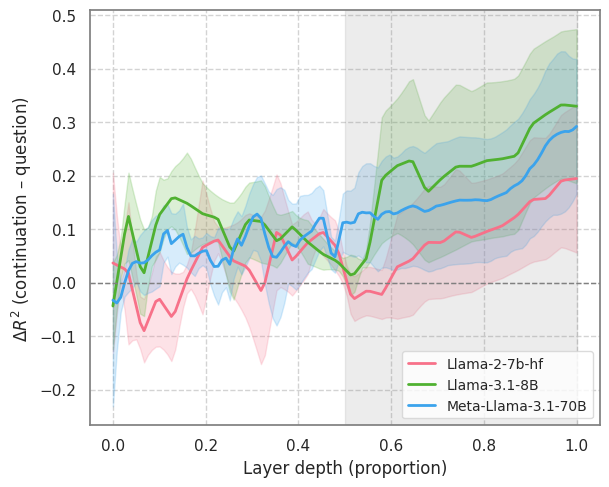

In [ ]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem
import seaborn as sns

# === 0. Set plotting style with light grid lines ===
sns.set_theme(style='whitegrid', rc={
    'grid.color': 'lightgray',
    'grid.linestyle': '--',
    'axes.edgecolor': 'gray'
})

# === 1. Configuration: path to JSON files ===
base_dir = 'Results/non_matching'  # Update this path if needed

# === 2. Find all JSON files ===
json_files = glob.glob(os.path.join(base_dir, '*.json'))
if not json_files:
    raise FileNotFoundError(f"No JSON files found in {base_dir}. Please check the path.")

# === 3. Load data ===
data = {}
for fp in json_files:
    attribute = os.path.splitext(os.path.basename(fp))[0].replace('r2_scores_', '')
    with open(fp, 'r') as f:
        obj = json.load(f)
    data[attribute] = {}
    for key, arr in obj.items():
        if key.endswith('(Non-matching prompt)'):
            model = key.replace(' (Non-matching prompt)', '')
            slot = 'nonmatching'
        else:
            model = key
            slot = 'matching'
        data[attribute].setdefault(model, {})[slot] = np.array(arr, dtype=float)

# === 4. Depth grid ===
depth_grid = np.linspace(0, 1, 120)

# === 5. Compute ΔR² curves ===
model_deltas = {}
for attribute, models in data.items():
    for model, tokens in models.items():
        if 'matching' in tokens and 'nonmatching' in tokens:
            match_arr = tokens['matching']
            nonmatch_arr = tokens['nonmatching']
            depths = np.linspace(0, 1, len(match_arr))
            m_interp = np.interp(depth_grid, depths, match_arr)
            nm_interp = np.interp(depth_grid, depths, nonmatch_arr)
            delta = m_interp - nm_interp
            model_deltas.setdefault(model, []).append(delta)

# === 6. Plot with improved aspect ratio and legend ===
fig, ax = plt.subplots(figsize=(6, 5))

models = list(model_deltas.keys())
colors = sns.color_palette("husl", len(models))

for i, (model, deltas) in enumerate(model_deltas.items()):
    arr = np.vstack(deltas)
    mean_delta = arr.mean(axis=0)
    ci = 1.96 * sem(arr, axis=0)

    ax.plot(
        depth_grid, mean_delta,
        label=model,
        color=colors[i],
        linewidth=2
    )
    ax.fill_between(
        depth_grid,
        mean_delta - ci,
        mean_delta + ci,
        color=colors[i],
        alpha=0.2
    )

# Reference line
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axvspan(0.5, 1, color='gray', alpha=0.15)

# Labels
ax.set_xlabel('Layer depth (proportion)', fontsize=12)
ax.set_ylabel(r'$\Delta R^2$ (continuation – question)', fontsize=12)

# Compact legend
ax.legend(
    loc='lower right',
    ncol=1,
    handlelength=2,
    columnspacing=0.8,
    frameon=True,
    edgecolor='lightgray',
    fontsize=10,
    title_fontsize=11
)

plt.subplots_adjust(
    left=0.10,
    right=0.95,
    top=0.93,
    bottom=0.10
)

# Save and show
plt.savefig('Results/non_matching/non_matching_p.png', dpi=300, bbox_inches='tight')
plt.show()


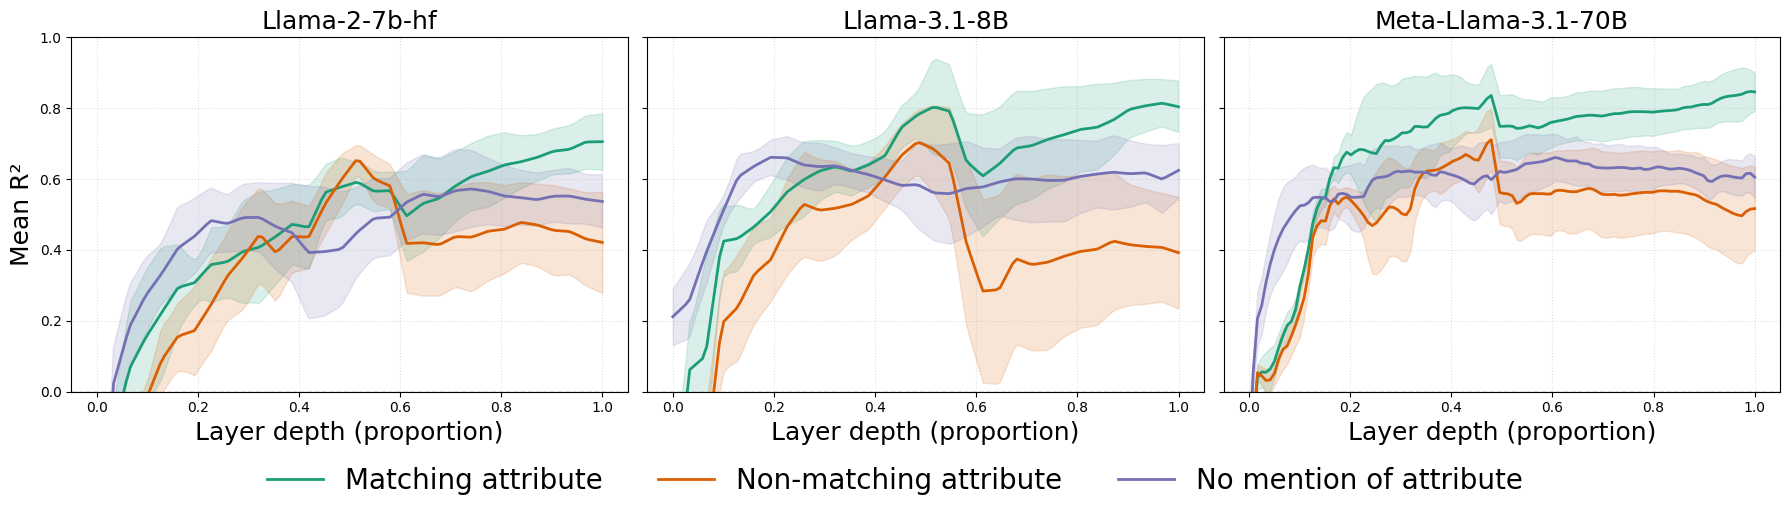

In [ ]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt

# === Configuration: paths to two folders ===
dir_element = '../Results/element_token'      # Contains (last token) and (element token)
dir_nonmatch = '../Results/non_matching'     # Contains (Non-matching prompt)

# 1. Collect all JSON files
files_elem = glob.glob(os.path.join(dir_element, '*.json'))
files_non  = glob.glob(os.path.join(dir_nonmatch, '*.json'))
if not files_elem:
    raise FileNotFoundError(f"No JSON files found in {dir_element}.")
if not files_non:
    raise FileNotFoundError(f"No JSON files found in {dir_nonmatch}.")

# 2. Load data
# 2.1 last & element under element_token
for fp in files_elem:
    with open(fp, 'r') as f:
        obj = json.load(f)
    for key, arr in obj.items():
        if key.endswith(' (last token)'):
            model = key[:-len(' (last token)')]
            cond = 'last'
        elif key.endswith(' (element token)'):
            model = key[:-len(' (element token)')]
            cond = 'element'
        else:
            continue
        data.setdefault(model, {}).setdefault(cond, []).append(np.array(arr, dtype=float))

# 2.2 non-matching prompt under non_matching
for fp in files_non:
    with open(fp, 'r') as f:
        obj = json.load(f)
    for key, arr in obj.items():
        if key.endswith(' (Non-matching prompt)'):
            model = key[:-len(' (Non-matching prompt)')]
            cond = 'nonmatching'
        else:
            continue
        data.setdefault(model, {}).setdefault(cond, []).append(np.array(arr, dtype=float))

# 3. Unified depth grid
depth_grid = np.linspace(0, 1, 120)

# 4. Prepare for plotting
models = sorted(data.keys())
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5), sharey=True)

label_map = {
    'last':       'Matching attribute',
    'nonmatching':'Non-matching attribute',
    'element':    'No mention of attribute'
}

# Use matplotlib's tab10 color palette
tab10_colors = plt.get_cmap('tab10').colors
color_map = {
    'last':        '#1b9e77',  # Dark green
    'nonmatching': '#d95f02',  # Orange
    'element':     '#7570b3'   # Purple
}
for ax, model in zip(axes, models):
    conds = data[model]
    for cond in ('last', 'nonmatching', 'element'):
        arrs = conds.get(cond, [])
        if not arrs:
            continue
        # Interpolate and stack
        interp_stack = []
        for arr in arrs:
            depths = np.linspace(0, 1, len(arr))
            interp = np.interp(depth_grid, depths, arr)
            interp_stack.append(interp)
        interp_stack = np.vstack(interp_stack)

        # Mean & 95% CI
        mean_curve = interp_stack.mean(axis=0)
        ci = 1.96 * np.std(interp_stack, axis=0, ddof=1) / np.sqrt(interp_stack.shape[0])

        # Plot (with color)
        ax.plot(depth_grid, mean_curve, label=label_map[cond], linewidth=2, color=color_map[cond])
        ax.fill_between(depth_grid,
                        mean_curve - ci,
                        mean_curve + ci,
                        alpha=0.16,
                        color=color_map[cond])

    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(model, fontsize=18, pad=6)
    ax.set_xlabel('Layer depth (proportion)', fontsize=18)
    if ax is axes[0]:
        ax.set_ylabel('Mean R²', fontsize=18)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.4)
    # save

# 5. Legend and layout
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,  loc='lower center',
           ncol=3, frameon=False, fontsize=20,
           bbox_to_anchor=(0.5, -0.12), bbox_transform=fig.transFigure)

fig.tight_layout(rect=[0, 0, 1, 0.93])
# Save figure
plt.savefig('../Results/element_token/combined_plot.png', dpi=300, bbox_inches='tight')
plt.show()


# p-value calculation

In [3]:
import numpy as np
from scipy.stats import norm
import os
import json
import glob
import pandas as pd
import mpmath as mp

# === 1. Configure path ===
json_folder = "../Results/non_matching"  # Modify to your JSON folder path
json_files = glob.glob(os.path.join(json_folder, "*.json"))

# === 2. Collect difference vectors ===
model_diffs = {}
for fp in json_files:
    attribute = os.path.splitext(os.path.basename(fp))[0]
    with open(fp, 'r', encoding='utf-8') as f:
        data = json.load(f)
    # Temporarily store matching/nonmatching for each model
    tmp = {}
    for key, arr in data.items():
        if key.endswith(" (Non-matching prompt)"):
            name = key[:-len(" (Non-matching prompt)")]
            tmp.setdefault(name, {})['nonmatching'] = np.array(arr, dtype=float)
        else:
            name = key  # Pure model name
            tmp.setdefault(name, {})['matching'] = np.array(arr, dtype=float)
    # For each model, if both exist, calculate diff
    for model, parts in tmp.items():
        if 'matching' in parts and 'nonmatching' in parts:
            diff = parts['matching'] - parts['nonmatching']
            model_diffs.setdefault(model, []).append((attribute, diff))
        else:
            print(f"[WARN] {attribute} / {model} missing matching or nonmatching, skipping")

# === 3. Mann–Kendall test function ===
def mann_kendall_test(x):
    n = len(x)
    S = 0
    for i in range(n-1):
        for j in range(i+1, n):
            S += np.sign(x[j] - x[i])
    # Ties correction
    _, counts = np.unique(x, return_counts=True)
    ties = counts[counts > 1]
    var_S = (n*(n-1)*(2*n+5) - np.sum(ties*(ties-1)*(2*ties+5))) / 18
    if S > 0:
        Z = (S - 1)/np.sqrt(var_S)
    elif S < 0:
        Z = (S + 1)/np.sqrt(var_S)
    else:
        Z = 0
    p = 2*(1 - norm.cdf(abs(Z)))
    tau = S / (0.5 * n * (n-1))
    return p, tau

# === 4. Perform test on the latter half of the interval and collect results ===
results = []
start_frac, end_frac = 0.6, 1.0
for model, vecs in model_diffs.items():
    for attribute, vec in vecs:
        n = len(vec)
        lo = int(start_frac * n)
        hi = int(end_frac * n)
        if lo >= hi:
            continue
        p, tau = mann_kendall_test(vec[lo:hi])
        results.append({
            'model': model,
            'attribute': attribute,
            'p_value': p,
            'tau': tau
        })

# === 5. BH correction and save to CSV ===
df = pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)
m = len(df)
df['bh_critical'] = (np.arange(1, m+1) / m) * 0.05
df['bh_significant'] = df['p_value'] <= df['bh_critical']

out_path = os.path.join("../Results", "non_matching", "mann_kendall_p_values.csv")
df.to_csv(out_path, index=False)
print("Saved to", out_path)

# === 6. Fisher combined p-value (optional) ===
p_list = df['p_value'].values
chi2 = -2 * np.sum(np.log(p_list[p_list>0]))
combined = mp.gammainc(len(p_list), chi2/2, mp.inf, regularized=True)
print("Combined p-value:", combined)


Saved to ../Results/non_matching/mann_kendall_p_values.csv
Combined p-value: 5.09200484978051e-62
